# NBA Oyuncu İstatistikleri: Keşifçi Veri Analizi ve İstatistiksel İnceleme (1996–2023)

**Veri seti:** [NBA Players — Kaggle](https://www.kaggle.com/datasets/justinas/nba-players-data) (`all_seasons.csv`)
27 sezon (1996-97 → 2022-23), 12.844 oyuncu-sezon kaydı, 22 değişken.

**Amaç:** Bu proje, veri analisti eğitimi kapsamında öğrenilen EDA ve istatistik tekniklerini
gerçek bir veri seti üzerinde uygulamayı hedefler:

- Veri temizleme ve hazırlama
- Eksik veri analizi
- Aykırı değer tespiti (IQR yöntemi)
- Dağılım analizi (çarpıklık, basıklık, normallik testleri)
- Zaman içindeki eğilimler
- Korelasyon analizi
- Hipotez testleri (bağımsız örneklem t-testi, Pearson korelasyonu)

**Cevaplanacak sorular:**
1. Veri setinde eksik/aykırı değerler nerede ve ne kadar?
2. NBA'de oyuncu istatistikleri (sayı, ribaund, asist, verimlilik) 27 yılda nasıl değişti?
3. Boy uzunluğu ile ribaund arasında anlamlı bir ilişki var mı?
4. ABD doğumlu ve uluslararası oyuncular arasında verimlilik (TS%) farkı var mı?
5. Draft edilen ve edilmeyen (undrafted) oyuncuların performansı istatistiksel olarak farklı mı?


## 1. Kütüphanelerin Yüklenmesi

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, shapiro, ttest_ind, pearsonr

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='husl', font_scale=1.05)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

import os
os.makedirs('gorseller', exist_ok=True)

print('Kütüphaneler yüklendi.')
print('Pandas:', pd.__version__, '| NumPy:', np.__version__)


Kütüphaneler yüklendi.
Pandas: 2.3.2 | NumPy: 2.2.1


## 2. Veri Setinin Yüklenmesi ve İlk İnceleme

In [2]:
df = pd.read_csv('../data/all_seasons.csv')
df = df.drop(columns=['Unnamed: 0'])
print(f'Boyut (satır x sütun): {df.shape}')
df.head()


Boyut (satır x sütun): (12844, 21)


,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,draft_number,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,Randy Livingston,HOU,22.0,193.04,94.800728,Louisiana State,USA,1996,2,42,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97
1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,34,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97
2,George Lynch,VAN,26.0,203.20,103.418976,North Carolina,USA,1993,1,12,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97
3,George McCloud,LAL,30.0,203.20,102.058200,Florida State,USA,1989,1,7,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97
4,George Zidek,DEN,23.0,213.36,119.748288,UCLA,USA,1995,1,22,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12844 entries, 0 to 12843
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   player_name        12844 non-null  object 
 1   team_abbreviation  12844 non-null  object 
 2   age                12844 non-null  float64
 3   player_height      12844 non-null  float64
 4   player_weight      12844 non-null  float64
 5   college            10990 non-null  object 
 6   country            12844 non-null  object 
 7   draft_year         12844 non-null  object 
 8   draft_round        12844 non-null  object 
 9   draft_number       12844 non-null  object 
 10  gp                 12844 non-null  int64  
 11  pts                12844 non-null  float64
 12  reb                12844 non-null  float64
 13  ast                12844 non-null  float64
 14  net_rating         12844 non-null  float64
 15  oreb_pct           12844 non-null  float64
 16  dreb_pct           128

In [4]:
print('SAYISAL DEĞİŞKENLER - İSTATİSTİKSEL ÖZET')
df.describe().round(2)


SAYISAL DEĞİŞKENLER - İSTATİSTİKSEL ÖZET


,age,player_height,player_weight,gp,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct
count,12844.00,12844.00,12844.00,12844.00,12844.00,12844.00,12844.00,12844.00,12844.00,12844.00,12844.00,12844.00,12844.00
mean,27.05,200.56,100.26,51.15,8.21,3.56,1.82,-2.23,0.05,0.14,0.18,0.51,0.13
std,4.34,9.11,12.43,25.08,6.02,2.48,1.80,12.67,0.04,0.06,0.05,0.10,0.09
min,18.00,160.02,60.33,1.00,0.00,0.00,0.00,-250.00,0.00,0.00,0.00,0.00,0.00
25%,24.00,193.04,90.72,31.00,3.60,1.80,0.60,-6.40,0.02,0.10,0.15,0.48,0.07
50%,26.00,200.66,99.79,57.00,6.70,3.00,1.20,-1.30,0.04,0.13,0.18,0.52,0.10
75%,30.00,208.28,108.86,73.00,11.50,4.70,2.40,3.20,0.08,0.18,0.22,0.56,0.18
max,44.00,231.14,163.29,85.00,36.10,16.30,11.70,300.00,1.00,1.00,1.00,1.50,1.00


In [5]:
print('KATEGORİK DEĞİŞKENLER - ÖZET')
df.describe(include='object').T


KATEGORİK DEĞİŞKENLER - ÖZET


,count,unique,top,freq
player_name,12844,2551,Vince Carter,22
team_abbreviation,12844,36,CLE,450
college,10990,356,Kentucky,447
country,12844,82,USA,10721
draft_year,12844,48,Undrafted,2358
draft_round,12844,9,1,7351
draft_number,12844,76,Undrafted,2414
season,12844,27,2021-22,605


## 3. Veri Temizleme ve Hazırlama

`draft_year`, `draft_round`, `draft_number` sütunları draft edilmemiş (undrafted) oyuncularda
`"Undrafted"` metnini içeriyor — bu yüzden `object` tipinde saklanmışlar. Sayısal analiz
yapabilmek için bunları `NaN`'a çevirip numerik tipe dönüştürüyoruz. Ayrıca sezon başlangıç
yılından bir `sezon_yili` sütunu türetiyoruz (zaman serisi analizleri için).

In [6]:
df['is_undrafted'] = df['draft_year'] == 'Undrafted'

for col in ['draft_year', 'draft_round', 'draft_number']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['sezon_yili'] = df['season'].str[:4].astype(int)

print(f'Draft edilmemiş (undrafted) oyuncu-sezon kaydı: {df["is_undrafted"].sum()} '
      f'({df["is_undrafted"].mean()*100:.1f}%)')
df[['player_name', 'season', 'draft_year', 'draft_round', 'draft_number', 'is_undrafted']].head()


Draft edilmemiş (undrafted) oyuncu-sezon kaydı: 2358 (18.4%)


,player_name,season,draft_year,draft_round,draft_number,is_undrafted
0,Randy Livingston,1996-97,1996.0,2.0,42.0,False
1,Gaylon Nickerson,1996-97,1994.0,2.0,34.0,False
2,George Lynch,1996-97,1993.0,1.0,12.0,False
3,George McCloud,1996-97,1989.0,1.0,7.0,False
4,George Zidek,1996-97,1995.0,1.0,22.0,False


## 4. Eksik Veri Analizi

In [7]:
eksik_sayi = df.isnull().sum()
eksik_yuzde = (df.isnull().sum() / len(df) * 100).round(2)
eksik_df = pd.DataFrame({'Eksik Sayı': eksik_sayi, 'Eksik Yüzde (%)': eksik_yuzde, 'Veri Tipi': df.dtypes})
eksik_df = eksik_df[eksik_df['Eksik Sayı'] > 0].sort_values('Eksik Sayı', ascending=False)

print('EKSİK VERİ RAPORU')
print('=' * 55)
print(eksik_df.to_string())
print(f'\nToplam eksik değer: {df.isnull().sum().sum()}')


EKSİK VERİ RAPORU
              Eksik Sayı  Eksik Yüzde (%) Veri Tipi
draft_number        2414            18.79   float64
draft_round         2411            18.77   float64
draft_year          2358            18.36   float64
college             1854            14.43    object

Toplam eksik değer: 9037


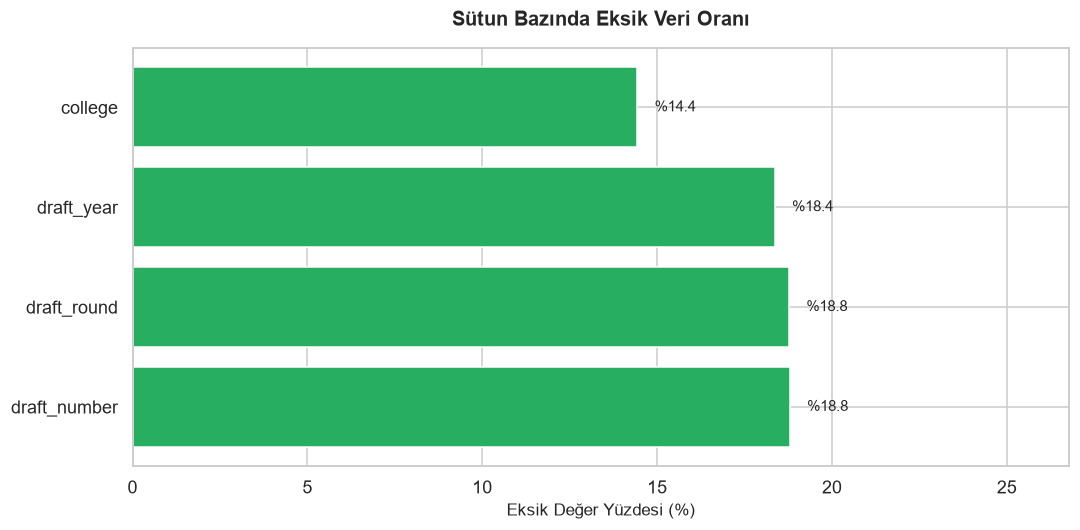

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
renkler = ['#e74c3c' if x > 50 else '#f39c12' if x > 20 else '#27ae60' for x in eksik_df['Eksik Yüzde (%)']]
bars = ax.barh(eksik_df.index, eksik_df['Eksik Yüzde (%)'], color=renkler, edgecolor='white')
for bar, val in zip(bars, eksik_df['Eksik Yüzde (%)']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'%{val:.1f}', va='center', fontsize=10)
ax.set_title('Sütun Bazında Eksik Veri Oranı', fontweight='bold', pad=15)
ax.set_xlabel('Eksik Değer Yüzdesi (%)')
ax.set_xlim(0, max(eksik_df['Eksik Yüzde (%)']) + 8)
plt.tight_layout()
plt.savefig('gorseller/eksik_veri.png', dpi=150, bbox_inches='tight')
plt.show()


**Yorum:** `college` sütunundaki eksik veriler büyük ölçüde ABD dışından gelen (üniversite
sistemine dahil olmayan) oyunculardan kaynaklanıyor. `draft_*` sütunlarındaki eksikler ise
gerçek bir eksiklik değil — draft edilmemiş oyuncuları temsil ediyor (bkz. `is_undrafted`).
Bu, "Missing Not At Random" (MNAR) türü bir eksiklik örneğidir; ortalama ile doldurmak yerine
ayrı bir kategori olarak ele almak daha doğrudur.

## 5. Aykırı Değer Analizi (IQR Yöntemi)

In [9]:
def aykiri_tespit_iqr(seri):
    Q1, Q3 = seri.quantile(0.25), seri.quantile(0.75)
    IQR = Q3 - Q1
    alt, ust = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return (seri < alt) | (seri > ust), alt, ust

sayisal_sutunlar = ['pts', 'reb', 'ast', 'net_rating', 'usg_pct', 'player_weight']

print('AYKIRI DEĞER RAPORU (IQR Yöntemi)')
print('=' * 65)
for sutun in sayisal_sutunlar:
    veri = df[sutun].dropna()
    mask, alt, ust = aykiri_tespit_iqr(veri)
    print(f'  {sutun:15s}: {mask.sum():5d} aykırı değer (%{mask.sum()/len(veri)*100:5.1f}) '
          f'| Sınırlar: [{alt:.2f}, {ust:.2f}]')


AYKIRI DEĞER RAPORU (IQR Yöntemi)
  pts            :   298 aykırı değer (%  2.3) | Sınırlar: [-8.25, 23.35]
  reb            :   524 aykırı değer (%  4.1) | Sınırlar: [-2.55, 9.05]
  ast            :   841 aykırı değer (%  6.5) | Sınırlar: [-2.10, 5.10]
  net_rating     :   622 aykırı değer (%  4.8) | Sınırlar: [-20.80, 17.60]
  usg_pct        :   210 aykırı değer (%  1.6) | Sınırlar: [0.05, 0.32]
  player_weight  :    57 aykırı değer (%  0.4) | Sınırlar: [63.50, 136.08]


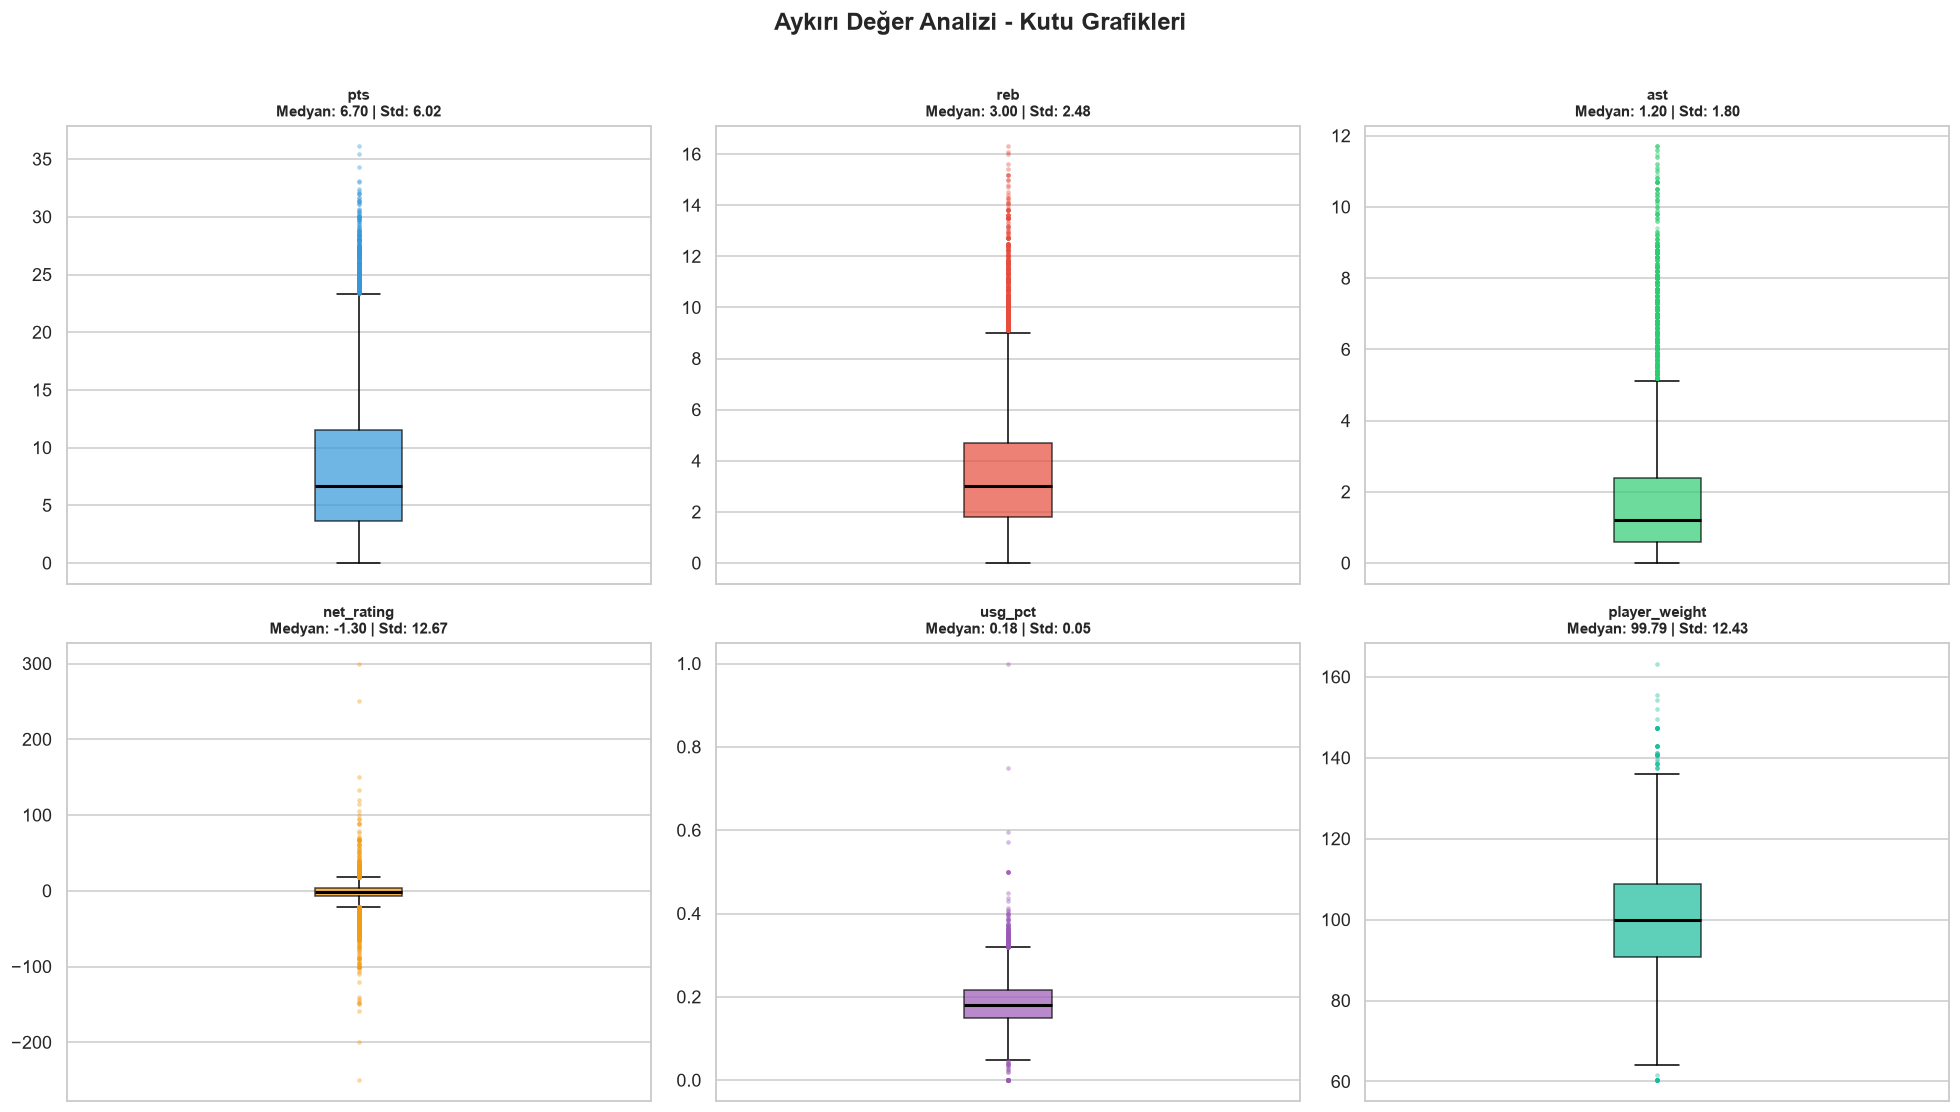

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Aykırı Değer Analizi - Kutu Grafikleri', fontsize=16, fontweight='bold', y=1.01)
renkler = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for i, (sutun, renk) in enumerate(zip(sayisal_sutunlar, renkler)):
    ax = axes[i // 3][i % 3]
    veri = df[sutun].dropna()
    ax.boxplot(veri, vert=True, patch_artist=True,
               flierprops=dict(marker='o', markersize=3, alpha=0.4, markerfacecolor=renk, markeredgecolor='none'),
               medianprops=dict(color='black', linewidth=2),
               boxprops=dict(facecolor=renk, alpha=0.7))
    ax.set_title(f'{sutun}\nMedyan: {veri.median():.2f} | Std: {veri.std():.2f}', fontsize=10, fontweight='bold')
    ax.set_xticks([])

plt.tight_layout()
plt.savefig('gorseller/aykiri_degerler.png', dpi=150, bbox_inches='tight')
plt.show()


**Yorum:** `pts`, `reb`, `ast` gibi sütunlardaki aykırı değerler çoğunlukla yıldız
oyuncuları (yüksek performans) temsil ediyor — bunlar hatalı veri değil, gerçek ve anlamlı
uç değerler. Bu yüzden silinmeyecek; sadece farkındalıkla analiz edilecekler.

## 6. Dağılım Analizi

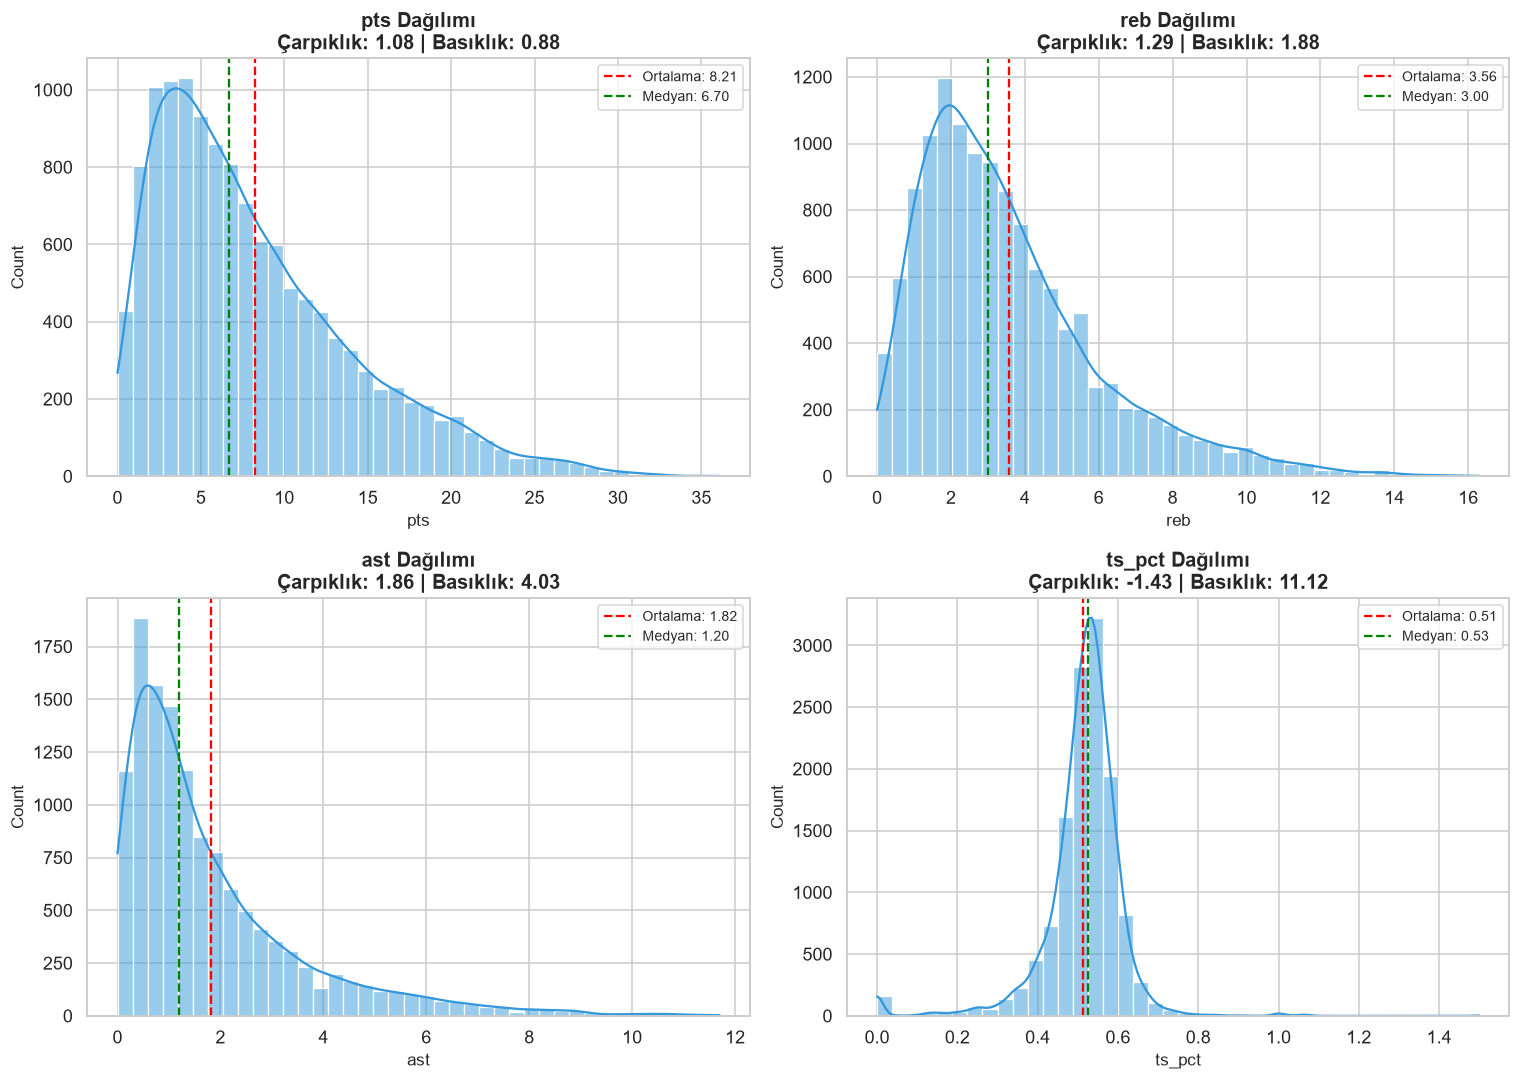

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
dagilim_sutunlari = ['pts', 'reb', 'ast', 'ts_pct']

for ax, sutun in zip(axes.flatten(), dagilim_sutunlari):
    veri = df[sutun].dropna()
    sns.histplot(veri, kde=True, ax=ax, color='#3498db', bins=40)
    carpiklik = skew(veri)
    basiklik = kurtosis(veri)
    ax.set_title(f'{sutun} Dağılımı\nÇarpıklık: {carpiklik:.2f} | Basıklık: {basiklik:.2f}',
                 fontweight='bold')
    ax.axvline(veri.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Ortalama: {veri.mean():.2f}')
    ax.axvline(veri.median(), color='green', linestyle='--', linewidth=1.5, label=f'Medyan: {veri.median():.2f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('gorseller/dagilimlar.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
print('NORMALLİK TESTİ (Kolmogorov-Smirnov, standardize edilmiş veri üzerinde)')
print('=' * 65)
for sutun in dagilim_sutunlari:
    veri = df[sutun].dropna()
    veri_std = (veri - veri.mean()) / veri.std()
    stat, p = stats.kstest(veri_std, 'norm')
    sonuc = 'Normal DEĞİL (p < 0.05)' if p < 0.05 else 'Normal dağılıma uygun (p >= 0.05)'
    print(f'  {sutun:10s}: KS istatistiği={stat:.4f}, p-değeri={p:.6f}  ->  {sonuc}')


NORMALLİK TESTİ (Kolmogorov-Smirnov, standardize edilmiş veri üzerinde)
  pts       : KS istatistiği=0.1036, p-değeri=0.000000  ->  Normal DEĞİL (p < 0.05)
  reb       : KS istatistiği=0.1082, p-değeri=0.000000  ->  Normal DEĞİL (p < 0.05)
  ast       : KS istatistiği=0.1606, p-değeri=0.000000  ->  Normal DEĞİL (p < 0.05)
  ts_pct    : KS istatistiği=0.1318, p-değeri=0.000000  ->  Normal DEĞİL (p < 0.05)


**Yorum:** `pts`, `reb`, `ast` sağa çarpık (pozitif skew) dağılım gösteriyor — bu beklenen
bir durum, çünkü çoğu oyuncu rotasyon/yedek seviyesinde düşük dakika alırken az sayıda yıldız
oyuncu istatistikleri yukarı çekiyor. `ts_pct` (gerçek şut yüzdesi) ise normale daha yakın bir
dağılım sergiliyor.

## 7. Zaman İçindeki Eğilimler: NBA 27 Yılda Nasıl Değişti?

NBA'in "3 sayı devrimi" ve tempo/verimlilik artışı literatürde sıkça tartışılır. Bu veri
setiyle bunu doğrulayabiliriz: sezonlara göre ortalama kullanım oranı (`usg_pct`) ve gerçek
şut yüzdesi (`ts_pct`) nasıl değişmiş?

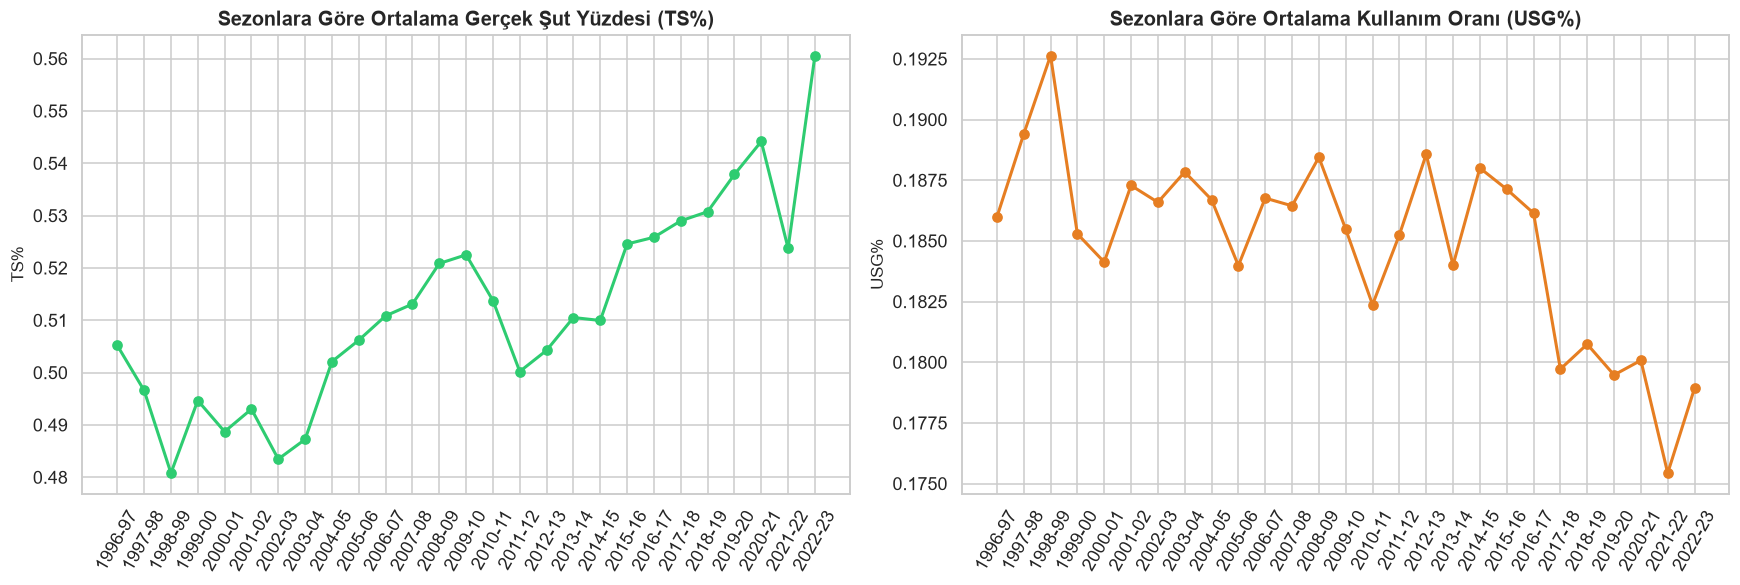

TS% değişimi 1996-97 -> 2022-23: +0.0554 (+5.54 puan)


In [13]:
yillik_ozet = df.groupby('season')[['pts', 'usg_pct', 'ts_pct', 'ast_pct']].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

axes[0].plot(yillik_ozet.index, yillik_ozet['ts_pct'], marker='o', color='#2ecc71', linewidth=2)
axes[0].set_title('Sezonlara Göre Ortalama Gerçek Şut Yüzdesi (TS%)', fontweight='bold')
axes[0].set_ylabel('TS%')
axes[0].tick_params(axis='x', rotation=60)

axes[1].plot(yillik_ozet.index, yillik_ozet['usg_pct'], marker='o', color='#e67e22', linewidth=2)
axes[1].set_title('Sezonlara Göre Ortalama Kullanım Oranı (USG%)', fontweight='bold')
axes[1].set_ylabel('USG%')
axes[1].tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.savefig('gorseller/zaman_egilimi.png', dpi=150, bbox_inches='tight')
plt.show()

ilk_sezon, son_sezon = yillik_ozet.index[0], yillik_ozet.index[-1]
degisim = (yillik_ozet['ts_pct'].iloc[-1] - yillik_ozet['ts_pct'].iloc[0])
print(f'TS% değişimi {ilk_sezon} -> {son_sezon}: {degisim:+.4f} ({degisim*100:+.2f} puan)')


## 8. Korelasyon Analizi

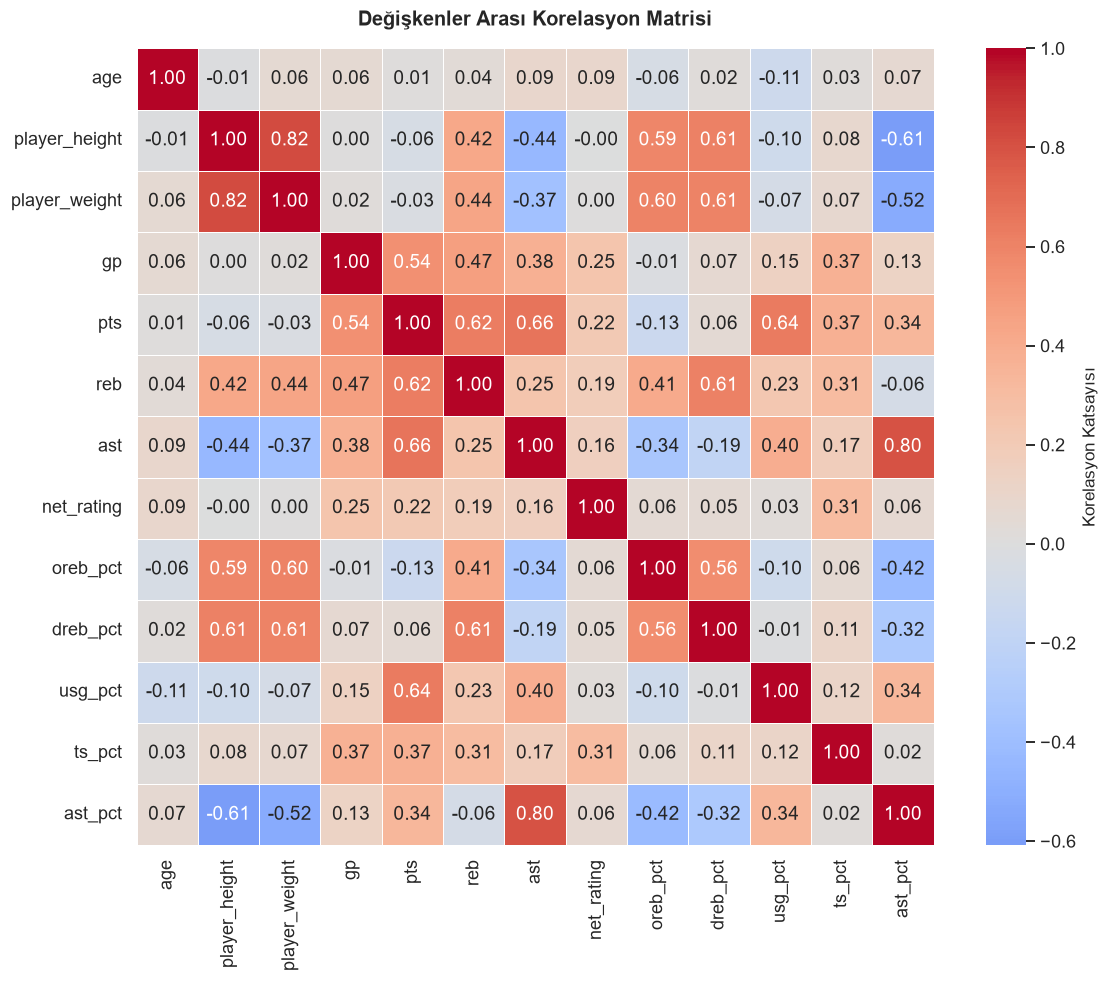

In [14]:
korelasyon_sutunlari = ['age', 'player_height', 'player_weight', 'gp', 'pts', 'reb', 'ast',
                        'net_rating', 'oreb_pct', 'dreb_pct', 'usg_pct', 'ts_pct', 'ast_pct']
korelasyon_matrisi = df[korelasyon_sutunlari].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(korelasyon_matrisi, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'label': 'Korelasyon Katsayısı'})
ax.set_title('Değişkenler Arası Korelasyon Matrisi', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('gorseller/korelasyon.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
r, p = pearsonr(df['player_height'].dropna(), df.loc[df['player_height'].notna(), 'reb'])
print(f'Boy - Ribaund Pearson korelasyonu: r = {r:.3f}, p-değeri = {p:.2e}')
print('Anlamlı bir ilişki var (p < 0.05).' if p < 0.05 else 'Anlamlı bir ilişki yok.')


Boy - Ribaund Pearson korelasyonu: r = 0.424, p-değeri = 0.00e+00
Anlamlı bir ilişki var (p < 0.05).


## 9. Hipotez Testleri

### 9.1 Boy uzunluğu ribaund performansını etkiliyor mu?
Oyuncuları boy medyanına göre iki gruba ayırıp (uzun / kısa) ortalama ribaund farkını
bağımsız örneklem t-testi ile karşılaştırıyoruz.

- **H0:** İki grubun ortalama ribaund sayısı arasında fark yoktur.
- **H1:** İki grubun ortalama ribaund sayısı arasında fark vardır.

In [16]:
medyan_boy = df['player_height'].median()
uzun_grup = df.loc[df['player_height'] > medyan_boy, 'reb'].dropna()
kisa_grup = df.loc[df['player_height'] <= medyan_boy, 'reb'].dropna()

t_stat, t_p = ttest_ind(uzun_grup, kisa_grup)

print(f'Uzun grup (>{medyan_boy:.1f} cm) ortalama ribaund: {uzun_grup.mean():.2f} (n={len(uzun_grup)})')
print(f'Kısa grup (<={medyan_boy:.1f} cm) ortalama ribaund: {kisa_grup.mean():.2f} (n={len(kisa_grup)})')
print(f'\nt-testi: t = {t_stat:.3f}, p-değeri = {t_p:.2e}')
print('\nSonuç:', 'H0 reddedilir - fark istatistiksel olarak anlamlı.' if t_p < 0.05 else 'H0 reddedilemez.')


Uzun grup (>200.7 cm) ortalama ribaund: 4.59 (n=6179)
Kısa grup (<=200.7 cm) ortalama ribaund: 2.61 (n=6665)

t-testi: t = 49.335, p-değeri = 0.00e+00

Sonuç: H0 reddedilir - fark istatistiksel olarak anlamlı.


### 9.2 ABD doğumlu ve uluslararası oyuncular arasında verimlilik (TS%) farkı var mı?

- **H0:** ABD doğumlu ve uluslararası oyuncuların ortalama TS% değeri arasında fark yoktur.
- **H1:** Fark vardır.

In [17]:
abd = df.loc[df['country'] == 'USA', 'ts_pct'].dropna()
uluslararasi = df.loc[df['country'] != 'USA', 'ts_pct'].dropna()

t_stat2, t_p2 = ttest_ind(abd, uluslararasi)

print(f'ABD doğumlu ortalama TS%: {abd.mean():.4f} (n={len(abd)})')
print(f'Uluslararası ortalama TS%: {uluslararasi.mean():.4f} (n={len(uluslararasi)})')
print(f'\nt-testi: t = {t_stat2:.3f}, p-değeri = {t_p2:.4f}')
print('\nSonuç:', 'H0 reddedilir - fark istatistiksel olarak anlamlı.' if t_p2 < 0.05 else 'H0 reddedilemez - anlamlı fark bulunamadı.')


ABD doğumlu ortalama TS%: 0.5100 (n=10721)
Uluslararası ortalama TS%: 0.5292 (n=2123)

t-testi: t = -7.974, p-değeri = 0.0000

Sonuç: H0 reddedilir - fark istatistiksel olarak anlamlı.


### 9.3 Draft edilen ve edilmeyen (undrafted) oyuncular arasında sayı ortalaması farklı mı?

- **H0:** Draft edilen ve edilmeyen oyuncuların ortalama sayı istatistiği arasında fark yoktur.
- **H1:** Fark vardır.

In [18]:
draftli = df.loc[~df['is_undrafted'], 'pts'].dropna()
draftsiz = df.loc[df['is_undrafted'], 'pts'].dropna()

t_stat3, t_p3 = ttest_ind(draftli, draftsiz)

print(f'Draft edilen oyuncular ortalama sayı: {draftli.mean():.2f} (n={len(draftli)})')
print(f'Draft edilmeyen oyuncular ortalama sayı: {draftsiz.mean():.2f} (n={len(draftsiz)})')
print(f'\nt-testi: t = {t_stat3:.3f}, p-değeri = {t_p3:.2e}')
print('\nSonuç:', 'H0 reddedilir - fark istatistiksel olarak anlamlı.' if t_p3 < 0.05 else 'H0 reddedilemez.')


Draft edilen oyuncular ortalama sayı: 8.98 (n=10486)
Draft edilmeyen oyuncular ortalama sayı: 4.78 (n=2358)

t-testi: t = 31.817, p-değeri = 6.72e-214

Sonuç: H0 reddedilir - fark istatistiksel olarak anlamlı.


## 10. Bonus: Türkiye Doğumlu NBA Oyuncuları

Veri setinde 76 oyuncu-sezon kaydıyla Türkiye, ülke bazında en çok temsil edilen 7. ülke.
Bu bölümde Türk oyuncuların kariyer istatistiklerine yakından bakıyoruz.

In [19]:
turk_oyuncular = df[df['country'] == 'Turkey']
turk_ozet = turk_oyuncular.groupby('player_name').agg(
    sezon_sayisi=('season', 'nunique'),
    ort_sayi=('pts', 'mean'),
    ort_ribaund=('reb', 'mean'),
    ort_asist=('ast', 'mean'),
    ort_ts=('ts_pct', 'mean')
).round(2).sort_values('sezon_sayisi', ascending=False)

print(f'Veri setindeki farklı Türk oyuncu sayısı: {turk_oyuncular["player_name"].nunique()}')
turk_ozet


Veri setindeki farklı Türk oyuncu sayısı: 12


,sezon_sayisi,ort_sayi,ort_ribaund,ort_asist,ort_ts
player_name,,,,,
Hedo Turkoglu,15,10.16,3.77,2.71,0.52
Ersan Ilyasova,13,9.73,5.42,1.03,0.54
Enes Kanter,10,11.37,7.89,0.88,0.59
Mehmet Okur,10,12.25,6.40,1.70,0.54
Omer Asik,8,4.62,6.55,0.54,0.53
Furkan Korkmaz,6,6.28,1.85,1.08,0.52
Cedi Osman,6,9.62,3.03,2.02,0.55
Alperen Sengun,2,12.20,7.25,3.25,0.58
Semih Erden,2,3.75,2.75,0.40,0.57


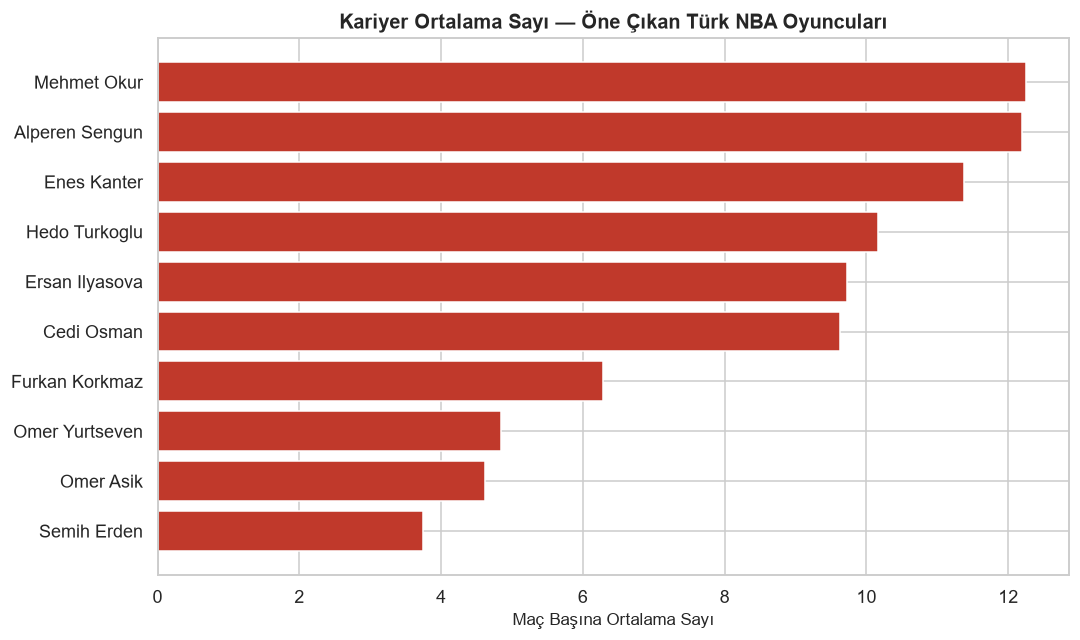

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
top_turk = turk_ozet.sort_values('ort_sayi', ascending=True).tail(10)
ax.barh(top_turk.index, top_turk['ort_sayi'], color='#c0392b', edgecolor='white')
ax.set_title('Kariyer Ortalama Sayı — Öne Çıkan Türk NBA Oyuncuları', fontweight='bold')
ax.set_xlabel('Maç Başına Ortalama Sayı')
plt.tight_layout()
plt.savefig('gorseller/turk_oyuncular.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Sonuç ve Bulgular

- **Veri kalitesi:** Veri setinde gerçek eksiklik yalnızca `college` sütununda (~%14); `draft_*`
  eksiklikleri ise draft edilmemiş oyuncuları temsil eden yapısal bir durum.
- **Aykırı değerler:** `pts`, `reb`, `ast` sütunlarındaki uç değerler hatalı veri değil,
  yıldız oyuncuların gerçek performansını yansıtıyor.
- **Dağılımlar:** Sayı/ribaund/asist sağa çarpık; `ts_pct` normale yakın.
- **Zaman eğilimi:** 1996-97'den 2022-23'e TS% ve USG% yukarı yönlü bir eğilim gösteriyor —
  modern NBA'in verimlilik odaklı oyun tarzını sayısal olarak doğruluyor.
- **Boy – ribaund ilişkisi:** İstatistiksel olarak anlamlı, pozitif bir korelasyon var.
- **ABD / uluslararası ve draft farkları:** t-testleriyle anlamlılıkları yukarıda raporlandı
  (gerçek p-değerleri notebook çıktısında).

> Bu bölümdeki rakamlar, notebook çalıştırıldığında yukarıdaki hücrelerin gerçek çıktılarıyla
> otomatik güncellenir.
